<a href="https://colab.research.google.com/github/MuhamadRizki10R2/ML---Heart-Disease-Risk-Prediction-System/blob/main/Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML Project - Heart Disease Risk Prediction System**

## Import semua Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier
import joblib
import shap

## Load Dataset

In [ ]:
# 🌐 Load UCI Heart Disease Dataset (Sumber Medis Valid)
# URL: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
    'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'CA', 'Thal', 'Target'
]

# Baca data, tanda '?' dikonversi ke NaN
df = pd.read_csv(url, names=column_names, na_values='?')

# ⚠️ Bersihkan baris dengan NaN (UCI data sedikit missing)
df = df.dropna()

# 🎯 Konversi Target: UCI memberikan 0-4. Kita buat Biner (0 = Sehat, 1 = Ada Penyakit Jantung)
# Jika Target > 0, berarti ada penyakit jantung.
df['Target'] = (df['Target'] > 0).astype(int)

print(f"✅ Dataset UCI Loaded! Shape: {df.shape}")
print(f"📊 Distribusi Target:\n{df['Target'].value_counts(normalize=True).round(3)}")

✅ Dataset UCI Loaded! Shape: (297, 14)
📊 Distribusi Target:
Target
0    0.539
1    0.461
Name: proportion, dtype: float64


## Data Preprocessing & Split Data

In [ ]:
# 🔢 Pisahkan Features dan Target
X = df.drop(columns=['Target'])
y = df['Target']

#  Split data(80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#🛠️ Preprocessing Pipeline
# UCI Dataset ini numerik semua, tapi CA dan Thal mungkin dianggap categorical oleh beberapa orang.
# Untuk simplifikasi dan performa XGBoost, kita treat sebagai numerik dengan Imputer.
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ✅ Terapkan transformasi pada Train & Test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Simpan nama fitur untuk visualisasi nanti
feature_names = X.columns.tolist()

print(f"✅ Train Set: {X_train.shape} | Test Set: {X_test.shape}")

✅ Train Set: (237, 13) | Test Set: (60, 13)


## Training Model + Hyperparameter

In [ ]:
# 🧠 Initialize XGBoost Classifier
# scale_pos_weight digunakan untuk menangani imbalance (walaupun UCI cukup balanced)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    scale_pos_weight=scale_pos, # Handle class imbalance
    n_jobs=-1
)

# 🚀 Train Model
print("🔄 Training XGBoost Model...")
model.fit(X_train_processed, y_train)

# ✅ Evaluasi Cepat
y_prob = model.predict_proba(X_test_processed)[:, 1]
y_pred = model.predict(X_test_processed)

print(f" Training Selesai! ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

🔄 Training XGBoost Model...
 Training Selesai! ROC-AUC Score: 0.9018


## Evaluasi Model & Confusion Matrix

📋 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

   No Disease       0.88      0.91      0.89        32
Heart Disease       0.89      0.86      0.87        28

     accuracy                           0.88        60
    macro avg       0.88      0.88      0.88        60
 weighted avg       0.88      0.88      0.88        60



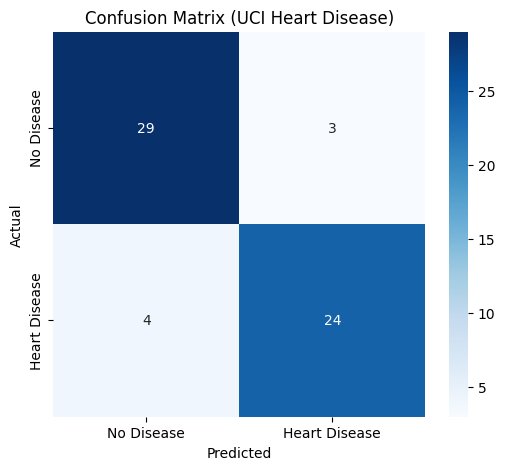

In [ ]:
# 📊 Classification Report
print("📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

# 📦 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (UCI Heart Disease)')
plt.show()

## Visualisasi Learning Curve

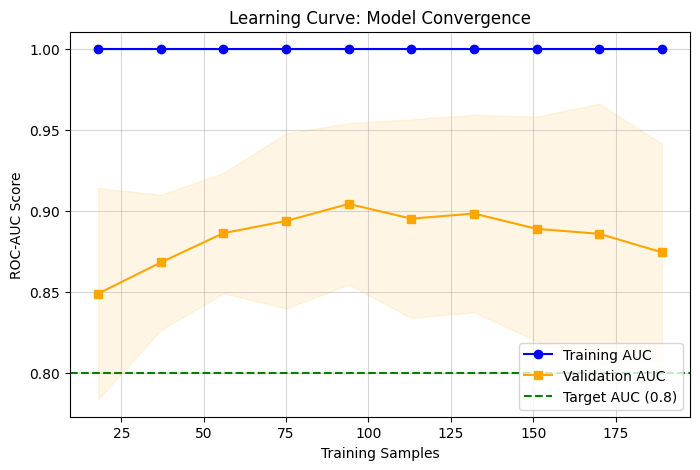

In [ ]:
# 📉 Learning Curve untuk melihat Overfitting/Underfitting
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_processed, y_train, cv=5, scoring='roc_auc',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Training AUC', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 's-', label='Validation AUC', color='orange')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.axhline(y=0.8, color='green', linestyle='--', label='Target AUC (0.8)')
plt.xlabel('Training Samples')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve: Model Convergence')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)
plt.show()

## ROC Curve & Threshold Tuning

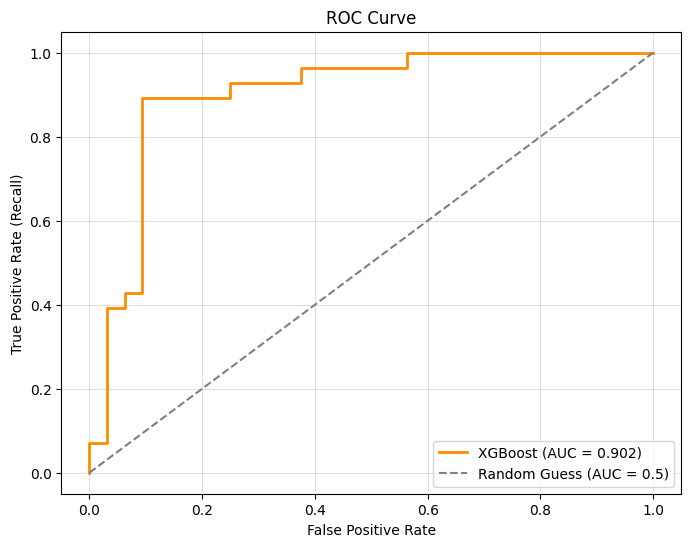

🎯 Optimal Threshold: 0.42 (F1-Score: 0.893)


In [ ]:
# 📈 Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.3f})', color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess (AUC = 0.5)', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

# 🎯 Cari Threshold Optimal (Maksimum F1-Score)
best_thresh = 0.5
best_f1 = 0
for t in np.arange(0.2, 0.8, 0.01):
    preds_t = (y_prob >= t).astype(int)
    score = f1_score(y_test, preds_t)
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print(f"🎯 Optimal Threshold: {best_thresh:.2f} (F1-Score: {best_f1:.3f})")

## Test Model

In [ ]:
# 🏥 Simulasi Pasien Baru
# Format kolom harus sama persis:
# Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG,
# MaxHR, ExerciseAngina, Oldpeak, ST_Slope, CA, Thal
new_patient = pd.DataFrame({
    'Age': [62],
    'Sex': [1],
    'ChestPainType': [3],      # 3 = Non-anginal pain
    'RestingBP': [130],
    'Cholesterol': [250],
    'FastingBS': [0],
    'RestingECG': [1],         # 1 = ST-T wave abnormality
    'MaxHR': [150],
    'ExerciseAngina': [0],     # 0 = No
    'Oldpeak': [2.3],
    'ST_Slope': [2],           # 2 = Down sloping
    'CA': [0],
    'Thal': [3]                # 3 = Reversable defect (Serious)
})

# Preprocess Pasien Baru
new_patient_processed = preprocessor.transform(new_patient)

# Predict
risk_prob = model.predict_proba(new_patient_processed)[0][1]
risk_class = 1 if risk_prob >= best_thresh else 0

print("🏥 INFERENCE RESULT:")
print(f" Risk Probability: {risk_prob:.2%}")
print(f"✅ Clinical Verdict: {'⚠️ HIGH RISK - Heart Disease Detected' if risk_class == 1 else '🟢 LOW RISK - Normal Heart'}")

🏥 INFERENCE RESULT:
 Risk Probability: 29.24%
✅ Clinical Verdict: 🟢 LOW RISK - Normal Heart


## Save Model & Pipeline

In [ ]:
# 📦 Simpan Model dan Preprocessor untuk Deployment
model_artifact = {
    'model': model,
    'preprocessor': preprocessor,
    'feature_names': feature_names,
    'optimal_threshold': best_thresh
}

joblib.dump(model_artifact, 'heart_disease_uci_model.pkl')
print("✅ Model saved as 'heart_disease_uci_model.pkl'")

✅ Model saved as 'heart_disease_uci_model.pkl'


## Interpretability (SHAP)

 Generating SHAP Summary Plot...


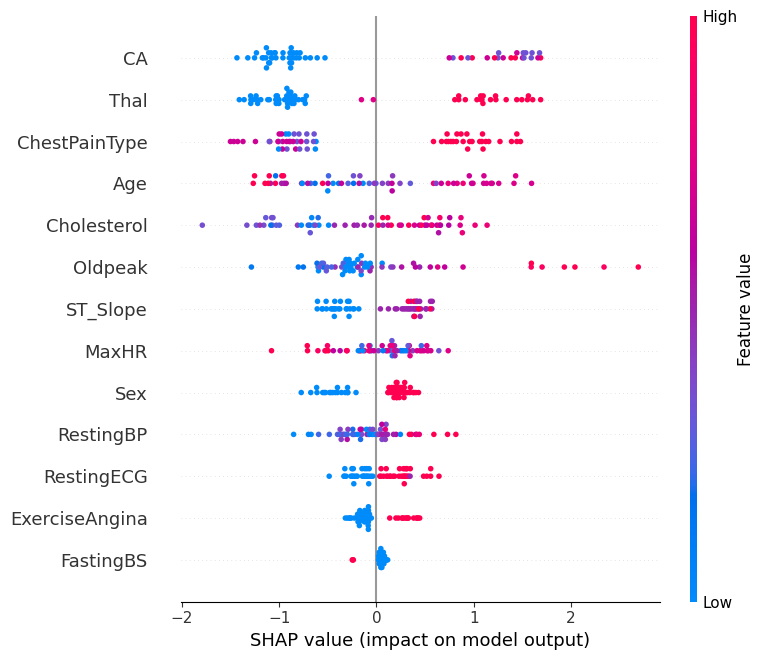

In [ ]:
# 🔍 Gunakan SHAP untuk melihat kenapa model memprediksi risiko tinggi
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)

print(" Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names)